# Image Forgery Detection: 

In [8]:
# Install dependencies
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'scikit-learn', 'tqdm'], check=True)

import os
import io
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Using device: {device}')


✓ Using device: cuda


## Multi-Dataset Loading + ELA / JPEG-Ghost Features

In [9]:
# ── ELA and JPEG Ghost helpers ────────────────────────────────────────────────

def compute_ela(pil_img, quality=90, scale=15):
    """
    Error Level Analysis: re-save at `quality` and measure per-pixel difference.
    Forged regions that were previously saved at a different quality level show
    elevated error — they stand out because their compression history differs.
    Returns a PIL grayscale image.
    """
    pil_img = pil_img.convert("RGB")
    buf = io.BytesIO()
    pil_img.save(buf, "JPEG", quality=quality)
    buf.seek(0)
    recomp = Image.open(buf).convert("RGB")
    ela = np.abs(np.array(pil_img, dtype=np.float32) - np.array(recomp, dtype=np.float32))
    ela = np.clip(ela.mean(axis=2) * scale, 0, 255).astype(np.uint8)
    return Image.fromarray(ela, mode='L')


def compute_jpeg_ghost(pil_img, qualities=(70, 80, 90)):
    """
    JPEG Ghost: re-save at multiple quality levels and measure difference.
    Authentic blocks show a ghost minimum at their original quality factor;
    spliced/copy-moved blocks (from a different source image) don't —
    their minimum sits at a different quality level.
    Returns a list of 3 grayscale (H, W) uint8 arrays, one per quality.
    """
    pil_img = pil_img.convert("RGB")
    orig = np.array(pil_img, dtype=np.float32)
    channels = []
    for q in qualities:
        buf = io.BytesIO()
        pil_img.save(buf, "JPEG", quality=q)
        buf.seek(0)
        recomp = np.array(Image.open(buf).convert("RGB"), dtype=np.float32)
        diff = np.clip(np.abs(orig - recomp).mean(axis=2) * 10, 0, 255).astype(np.uint8)
        channels.append(diff)
    return channels   # list of 3 (H, W) arrays


# ── Dataset-specific loaders ──────────────────────────────────────────────────
# Each dataset has a unique directory layout, so we use targeted loaders
# instead of a generic folder-name heuristic.

VALID_EXT = ('.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp')

def _collect(folder, label):
    """Return (paths, labels) for every image file directly inside folder."""
    paths = []
    if not os.path.isdir(folder):
        return [], []
    for f in os.listdir(folder):
        if f.lower().endswith(VALID_EXT):
            paths.append(os.path.join(folder, f))
    return paths, [label] * len(paths)


def load_casia2(root="/kaggle/input/datasets/chongtrung/casia-v2"):
    """
    CASIA v2 structure:
      root/CASIA2/Au/   → authentic (label 0)
      root/CASIA2/Tp/   → tampered  (label 1)
    """
    casia2 = os.path.join(root, "CASIA2")
    file_paths, labels = [], []
    for dirname, label in [("Au", 0), ("Tp", 1)]:
        folder = os.path.join(casia2, dirname)
        if not os.path.isdir(folder):
            # case-insensitive fallback
            for d in os.listdir(casia2):
                if d.lower() == dirname.lower():
                    folder = os.path.join(casia2, d)
                    break
        p, l = _collect(folder, label)
        file_paths.extend(p); labels.extend(l)
    return file_paths, labels


def load_defacto_copymove(root="/kaggle/input/datasets/defactodataset/defactocopymove"):
    """
    DEFACTO copy-move structure:
      root/copymove_img/img/   → all tampered (label 1)   [.tif images]
      root/copymove_annotations/  → masks/graphs, skip
    DEFACTO has no authentic images; authentic class comes from CASIA v2.
    """
    img_dir = os.path.join(root, "copymove_img", "img")
    return _collect(img_dir, label=1)


def load_defacto_splicing(root="/kaggle/input/datasets/defactodataset/defactosplicing"):
    """
    DEFACTO splicing structure:
      root/splicing_N_img/img/  → all tampered (label 1)  [.tif images]
      root/splicing_N_annotations/  → probe_mask (.jpg masks), donor_mask, graph — skip
    Scans all splicing_*_img subdirectories.
    """
    file_paths, labels = [], []
    for dirname in sorted(os.listdir(root)):
        # Only image directories, not annotation directories
        if "img" in dirname and "annotation" not in dirname:
            img_dir = os.path.join(root, dirname, "img")
            p, l = _collect(img_dir, label=1)
            file_paths.extend(p); labels.extend(l)
    return file_paths, labels


# ── Augmentation (spatial only — applied to PIL before ELA/ghost) ─────────────

IMG_SIZE = 256

_spatial_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    # No blur / JPEG re-compression: would destroy the compression fingerprint.
])
_spatial_val = transforms.Resize((IMG_SIZE, IMG_SIZE))
_to_tensor   = transforms.ToTensor()


class ForgeryDataset(Dataset):
    """
    Returns (B, 7, H, W) tensors: RGB(3) + ELA(1) + Ghost×3(3).

    Spatial augmentation is applied to the PIL image first so that
    ELA and ghost are computed on the already-augmented image,
    keeping all 7 channels geometrically consistent.
    """
    def __init__(self, file_paths, labels, is_train=True):
        self.file_paths = file_paths
        self.labels     = labels
        self.spatial    = _spatial_train if is_train else _spatial_val

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.file_paths[idx]).convert("RGB")
        except Exception:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (128, 128, 128))

        img       = self.spatial(img)                  # PIL, spatially augmented
        ela       = compute_ela(img)                   # PIL 'L'  (1 ch)
        ghosts    = compute_jpeg_ghost(img)            # list of 3 (H,W) arrays

        img_t     = _to_tensor(img)                                              # (3,H,W)
        ela_t     = _to_tensor(ela)                                              # (1,H,W)
        ghost_t   = torch.stack(
            [_to_tensor(Image.fromarray(g, mode='L'))[0] for g in ghosts], dim=0
        )                                                                        # (3,H,W)

        combined  = torch.cat([img_t, ela_t, ghost_t], dim=0)                   # (7,H,W)
        return combined, torch.tensor(self.labels[idx], dtype=torch.long)

print("✓ ELA / JPEG-Ghost helpers loaded")
print("✓ Universal dataset loader (CASIA v2 + DEFACTO) loaded")
print("✓ ForgeryDataset (7-channel output) loaded")


✓ ELA / JPEG-Ghost helpers loaded
✓ Universal dataset loader (CASIA v2 + DEFACTO) loaded
✓ ForgeryDataset (7-channel output) loaded


## DCT Statistical Feature Extraction

**The Key Innovation:**
Extract 7 statistical features from DCT blocks that reveal forgery:
1. Low-frequency energy (DC + corner AC coefficients)
2. High-frequency energy (AC coefficients in upper right)
3. Entropy (randomness measure)
4. Mean coefficient value
5. Variance
6. Kurtosis (peakedness - 4th moment)
7. Skewness (asymmetry - 3rd moment)

In [10]:
def make_dct_matrix(N=8):
    """DCT-II basis matrix (orthonormal)."""
    k = torch.arange(N, dtype=torch.float32)
    n = torch.arange(N, dtype=torch.float32)
    D = torch.cos(torch.pi * k.unsqueeze(1) * (2 * n.unsqueeze(0) + 1) / (2 * N))
    D[0] *= 1.0 / (N ** 0.5)
    D[1:] *= (2.0 / N) ** 0.5
    return D


def extract_dct_statistical_features(gray_image, block_size=8):
    """
    12 JPEG-artifact-sensitive DCT features per 8×8 block.
    gray_image : (B, 1, H, W) → (B, 12, H//8, W//8)
    """
    B, _, H, W = gray_image.shape
    nh, nw = H // block_size, W // block_size
    gray = gray_image[:, :, :nh * block_size, :nw * block_size]

    patches = F.unfold(gray, kernel_size=block_size, stride=block_size)
    patches = patches.view(B, block_size, block_size, nh * nw).permute(0, 3, 1, 2)

    D = make_dct_matrix(block_size).to(gray.device)
    dct_blocks = D @ patches @ D.t()
    abs_dct = torch.abs(dct_blocks)
    EPS = 1e-8

    features = []
    features.append(dct_blocks[:, :, 0, 0])                                                    # 1. DC

    low_ac = torch.sum(abs_dct[:, :, :3, :3], dim=(-2, -1)) - abs_dct[:, :, 0, 0]
    features.append(low_ac)                                                                      # 2. Low-freq AC
    features.append(torch.sum(abs_dct[:, :, 2:6, 2:6], dim=(-2, -1)))                          # 3. Mid-freq
    features.append(torch.sum(abs_dct[:, :, 4:, 4:], dim=(-2, -1)))                            # 4. High-freq
    features.append(torch.sum(abs_dct[:, :, 0, 1:], dim=-1))                                   # 5. Horiz AC
    features.append(torch.sum(abs_dct[:, :, 1:, 0], dim=-1))                                   # 6. Vert AC

    ac_flat = dct_blocks.view(B, nh * nw, -1)[:, :, 1:]
    features.append((torch.abs(ac_flat) < 0.5).float().mean(dim=-1))                           # 7. Zero-AC ratio

    denom = torch.sum(abs_dct, dim=(-2, -1), keepdim=True) + EPS
    prob  = abs_dct / denom
    features.append(-torch.sum(prob * torch.log(prob + EPS), dim=(-2, -1)))                    # 8. Entropy

    var_coeff = torch.var(dct_blocks, dim=(-2, -1))
    features.append(var_coeff)                                                                   # 9. Variance

    mean_v = dct_blocks.mean(dim=(-2, -1), keepdim=True)
    std_v  = (var_coeff + EPS).sqrt().unsqueeze(-1).unsqueeze(-1)
    norm   = (dct_blocks - mean_v) / std_v
    features.append(torch.mean(norm ** 4, dim=(-2, -1)) - 3)                                   # 10. Kurtosis
    features.append(torch.mean(norm ** 3, dim=(-2, -1)))                                       # 11. Skewness
    features.append((torch.sum(abs_dct[:, :, 4:, 4:], dim=(-2,-1)) + EPS) / (low_ac + EPS))   # 12. H/L ratio

    return torch.stack(features, dim=1).view(B, 12, nh, nw)


def extract_fft_block_features(gray_image, block_size=8):
    """
    6 FFT-based features per 8×8 block.

    DCT captures JPEG quantisation fingerprints (energy levels).
    FFT adds:
      - Phase variance  → resampling artefacts (interpolation smears phase)
      - Periodic energy → copy-move forgeries produce periodic FFT patterns
      - Spectral entropy → another view of the frequency distribution

    gray_image : (B, 1, H, W) → (B, 6, H//8, W//8)
    """
    B, _, H, W = gray_image.shape
    nh, nw = H // block_size, W // block_size
    gray = gray_image[:, :, :nh * block_size, :nw * block_size]

    patches = F.unfold(gray, kernel_size=block_size, stride=block_size)
    patches = patches.view(B, block_size, block_size, nh * nw).permute(0, 3, 1, 2)  # (B, P, 8, 8)

    fft2  = torch.fft.fft2(patches)   # complex (B, P, 8, 8)
    mag   = torch.abs(fft2)           # magnitude spectrum
    phase = torch.angle(fft2)         # phase spectrum

    # Shift DC to centre for clean radial band separation
    half = block_size // 2
    mag_s = torch.roll(mag, shifts=(half, half), dims=(-2, -1))

    EPS = 1e-8
    features = []

    # 1. Low-freq energy  (inner 4×4 of centred spectrum, excluding DC itself)
    low = torch.sum(mag_s[:, :, half-2:half+2, half-2:half+2], dim=(-2, -1))
    features.append(low)

    # 2. High-freq energy (outer border of centred spectrum)
    high = (torch.sum(mag_s[:, :, :2,  :],    dim=(-2,-1)) +
            torch.sum(mag_s[:, :, 6:,  :],    dim=(-2,-1)) +
            torch.sum(mag_s[:, :, 2:6, :2],   dim=(-2,-1)) +
            torch.sum(mag_s[:, :, 2:6, 6:],   dim=(-2,-1)))
    features.append(high)

    # 3. Phase variance — resampling/interpolation scrambles phase;
    #    authentic JPEG blocks have relatively consistent phase structure
    features.append(phase.var(dim=(-2, -1)))

    # 4. Horizontal freq energy (non-DC row 0 of unshifted FFT)
    features.append(torch.sum(mag[:, :, 0, 1:], dim=-1))

    # 5. Vertical freq energy (non-DC col 0)
    features.append(torch.sum(mag[:, :, 1:, 0], dim=-1))

    # 6. Spectral entropy — copy-move blocks share content, flattening the spectrum
    mag_flat = mag.reshape(B, nh * nw, -1)
    prob_f   = mag_flat / (mag_flat.sum(dim=-1, keepdim=True) + EPS)
    features.append((-prob_f * torch.log(prob_f + EPS)).sum(dim=-1))

    return torch.stack(features, dim=1).view(B, 6, nh, nw)


# Sanity checks
_g = torch.randn(2, 1, 256, 256)
assert extract_dct_statistical_features(_g).shape == (2, 12, 32, 32)
assert extract_fft_block_features(_g).shape        == (2,  6, 32, 32)
print("✓ DCT features : (B,1,256,256) → (B,12,32,32)")
print("✓ FFT features : (B,1,256,256) → (B, 6,32,32)")
print("✓ Feature extractors ready (8×8 and 16×16 block sizes supported)")


✓ DCT features : (B,1,256,256) → (B,12,32,32)
✓ FFT features : (B,1,256,256) → (B, 6,32,32)
✓ Feature extractors ready (8×8 and 16×16 block sizes supported)


## Improved Frequency Branch

Key changes vs baseline:
- **7-channel input** (RGB + ELA + JPEG-Ghost×3) — ELA and Ghost expose double-compression artifacts directly
- **Multi-scale DCT**: 8×8 *and* 16×16 blocks — catches boundary artifacts that span multiple JPEG blocks
- **72 input feature channels** (30 raw DCT/FFT + 30 local-anomaly + 12 ELA/Ghost block features)
- **Deeper encoder**: 3 ResBlocks per stage instead of 2
- Output shape stays `(B, 128, 8, 8)` — compatible with cross-attention fusion


In [11]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        mid = max(channels // reduction, 8)
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, mid), nn.ReLU(inplace=True),
            nn.Linear(mid, channels), nn.Sigmoid(),
        )
    def forward(self, x):
        return x * self.fc(x).view(x.shape[0], x.shape[1], 1, 1)


class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1, bias=False), nn.BatchNorm2d(channels), nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, 1, 1, bias=False), nn.BatchNorm2d(channels),
        )
        self.se   = SEBlock(channels)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.relu(x + self.se(self.body(x)))


class StatisticalDCTFrequencyBranch(nn.Module):
    """
    Frequency branch accepting (B, 7, H, W): RGB(3) + ELA(1) + Ghost×3(3).

    Feature pipeline:
      gray  → 12 DCT @8×8  + 12 DCT @16×16 (upsampled) + 6 FFT  = 30 raw channels
            + 30 local-anomaly channels (each block vs 3×3 neighbourhood)
            = 60 DCT/FFT channels
      ELA + Ghost (4 ch) → avg-pool + max-pool per 8×8 block + local anomaly
            = 12 ELA/Ghost channels
      Total = 72 channels into the ResNet-SE encoder.

    Output: (B, out_channels, 8, 8) — compatible with cross-attention fusion.
    """
    IN_CH = 72

    def __init__(self, out_channels=128):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv2d(self.IN_CH, 64, 3, 1, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.layer1 = nn.Sequential(ResBlock(64),  ResBlock(64),  ResBlock(64))
        self.down1  = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        )
        self.layer2 = nn.Sequential(ResBlock(128), ResBlock(128), ResBlock(128))
        self.down2  = nn.Sequential(
            nn.Conv2d(128, out_channels, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d((8, 8))

    def forward(self, x):
        # x: (B, 7, H, W) = RGB(3) + ELA(1) + Ghost×3(3)
        gray = 0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3]  # (B,1,H,W)
        aux  = x[:, 3:]                                                       # (B,4,H,W)

        # Multi-scale DCT: 8×8 (JPEG native) + 16×16 (cross-block boundaries)
        dct8  = extract_dct_statistical_features(gray, block_size=8)          # (B,12,H/8, W/8)
        dct16 = extract_dct_statistical_features(gray, block_size=16)         # (B,12,H/16,W/16)
        dct16 = F.interpolate(dct16, size=dct8.shape[-2:], mode='bilinear', align_corners=False)
        fft8  = extract_fft_block_features(gray,       block_size=8)          # (B, 6,H/8, W/8)

        raw        = torch.log1p(torch.abs(torch.cat([dct8, dct16, fft8], dim=1)))  # (B,30,32,32)
        local_mean = F.avg_pool2d(raw, kernel_size=3, stride=1, padding=1)
        feats      = torch.cat([raw, raw - local_mean], dim=1)                       # (B,60,32,32)

        # ELA + Ghost: pool to block resolution, add local anomaly
        aux_avg    = F.avg_pool2d(aux, kernel_size=8, stride=8)                      # (B,4,32,32)
        aux_max    = F.max_pool2d(aux, kernel_size=8, stride=8)                      # (B,4,32,32)
        aux_lm     = F.avg_pool2d(aux_avg, kernel_size=3, stride=1, padding=1)
        aux_feats  = torch.cat([aux_avg, aux_max, aux_avg - aux_lm], dim=1)          # (B,12,32,32)

        feats = torch.cat([feats, aux_feats], dim=1)                                 # (B,72,32,32)

        x = self.stem(feats)
        x = self.layer1(x)
        x = self.down1(x)
        x = self.layer2(x)
        x = self.down2(x)
        return self.pool(x)    # (B, out_channels, 8, 8)


class StatisticalDCTClassifier(nn.Module):
    def __init__(self, out_channels=128):
        super().__init__()
        self.freq_branch = StatisticalDCTFrequencyBranch(out_channels)
        self.classifier  = nn.Sequential(
            nn.Flatten(),
            nn.Linear(out_channels * 8 * 8, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(512, 128),                   nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(128, 2),
        )
    def forward(self, x):
        return self.classifier(self.freq_branch(x))


# Sanity check with 7-channel input
_m = StatisticalDCTClassifier(out_channels=128).to(device)
_i = torch.rand(2, 7, 256, 256).to(device)   # RGB + ELA + Ghost×3
with torch.no_grad():
    _o = _m(_i)
print(f"✓ Input  shape : {_i.shape}  (RGB + ELA + Ghost×3)")
print(f"✓ Output shape : {_o.shape}")
print(f"✓ Parameters   : {sum(p.numel() for p in _m.parameters()):,}")
del _m, _i, _o


✓ Input  shape : torch.Size([2, 7, 256, 256])  (RGB + ELA + Ghost×3)
✓ Output shape : torch.Size([2, 2])
✓ Parameters   : 5,664,978


## Load All Three Datasets

In [12]:
BATCH_SIZE  = 32
NUM_WORKERS = 4 if torch.cuda.is_available() else 0

# ── Load all three datasets ───────────────────────────────────────────────────
loaders = [
    ("CASIA v2",          load_casia2,
     "/kaggle/input/datasets/chongtrung/casia-v2"),
    ("DEFACTO copy-move", load_defacto_copymove,
     "/kaggle/input/datasets/defactodataset/defactocopymove"),
    ("DEFACTO splicing",  load_defacto_splicing,
     "/kaggle/input/datasets/defactodataset/defactosplicing"),
]

all_paths, all_labels = [], []
for name, loader_fn, root in loaders:
    try:
        paths, lbs = loader_fn(root)
        if not paths:
            print(f"⚠  {name}: 0 images found — check path {root}")
            continue
        all_paths.extend(paths)
        all_labels.extend(lbs)
        print(f"✓ {name}: {len(paths)} images "
              f"(authentic={lbs.count(0)}, tampered={lbs.count(1)})")
    except Exception as e:
        print(f"✗ {name}: {e}")

print(f"\n✓ Total: {len(all_paths)} images  "
      f"(authentic={all_labels.count(0)}, tampered={all_labels.count(1)})")

if not all_paths:
    raise RuntimeError("No images loaded — check dataset paths above.")

train_files, val_files, train_labels, val_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

train_dataset = ForgeryDataset(train_files, train_labels, is_train=True)
val_dataset   = ForgeryDataset(val_files,   val_labels,   is_train=False)

dataloader_kwargs = dict(
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True,
)
if NUM_WORKERS > 0:
    dataloader_kwargs["persistent_workers"] = True

train_loader = DataLoader(train_dataset, shuffle=True,  **dataloader_kwargs)
val_loader   = DataLoader(val_dataset,   shuffle=False, **dataloader_kwargs)

print(f"\n✓ Train: {len(train_dataset)} images → {len(train_loader)} batches")
print(f"✓ Val  : {len(val_dataset)} images → {len(val_loader)} batches")

class_weights = compute_class_weight("balanced", classes=np.unique(train_labels), y=train_labels)
class_weight  = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"✓ Class weights: {class_weight.cpu().numpy()}")

dataset_ready = True
print("\n" + "="*60)
print("DATASETS READY FOR TRAINING")
print("="*60)


✓ CASIA v2: 12614 images (authentic=7491, tampered=5123)
✓ DEFACTO copy-move: 18194 images (authentic=0, tampered=18194)
✓ DEFACTO splicing: 106392 images (authentic=0, tampered=106392)

✓ Total: 137200 images  (authentic=7491, tampered=129709)

✓ Train: 109760 images → 3430 batches
✓ Val  : 27440 images → 858 batches
✓ Class weights: [9.157351  0.5288772]

DATASETS READY FOR TRAINING


## Training Loop

In [13]:
# Dataset loading is now handled in the cell above (all three datasets combined).
# This cell is intentionally left as a no-op placeholder.
print("✓ Dataset loading complete — see cell above for details.")


✓ Dataset loading complete — see cell above for details.


## Train

In [14]:
if dataset_ready:
    model     = StatisticalDCTClassifier(out_channels=128).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weight, label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

    epochs    = 60
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=5e-4,
        steps_per_epoch=len(train_loader),
        epochs=epochs,
        pct_start=0.1,
        anneal_strategy='cos',
    )

    best_val_acc    = 0.0
    best_model_path = "best_statistical_dct_classifier.pth"
    patience        = 15
    patience_ctr    = 0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

    print(f"\n{'='*80}")
    print("TRAINING CONFIGURATION")
    print(f"{'='*80}")
    print(f"Input        : 7-channel (RGB + ELA + JPEG-Ghost×3)")
    print(f"Features     : 72ch (30 DCT@8+16 + 30 local-anomaly + 12 ELA/Ghost blocks)")
    print(f"Loss         : CrossEntropyLoss (label_smoothing=0.1, class-weighted)")
    print(f"Optimizer    : AdamW (lr=3e-4, wd=1e-4)")
    print(f"Scheduler    : OneCycleLR (max_lr=5e-4, {epochs} epochs)")
    print(f"Epochs       : {epochs}  (early stop @ patience={patience})")
    print(f"{'='*80}\n")

    for epoch in range(epochs):
        # ── Train ──────────────────────────────────────────────────────────────
        model.train()
        run_loss = correct = total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{epochs} [Train]", leave=False)
        for images, targets in loop:
            images, targets = images.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            run_loss += loss.item() * images.size(0)
            _, preds  = outputs.max(1)
            total    += targets.size(0)
            correct  += preds.eq(targets).sum().item()
            loop.set_postfix(loss=f"{loss.item():.4f}")

        t_loss = run_loss / max(total, 1)
        t_acc  = correct  / max(total, 1) * 100

        # ── Validate ───────────────────────────────────────────────────────────
        model.eval()
        v_loss = v_correct = v_total = 0
        v_preds, v_targets, v_probs = [], [], []

        with torch.no_grad():
            for images, targets in tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{epochs} [Val]  ", leave=False):
                images, targets = images.to(device), targets.to(device)
                outputs = model(images)
                v_loss  += criterion(outputs, targets).item() * images.size(0)
                _, preds = outputs.max(1)
                v_total   += targets.size(0)
                v_correct += preds.eq(targets).sum().item()
                v_preds.extend(preds.cpu().numpy())
                v_targets.extend(targets.cpu().numpy())
                v_probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())

        v_epoch_loss = v_loss    / max(v_total, 1)
        v_epoch_acc  = v_correct / max(v_total, 1) * 100
        v_epoch_f1   = f1_score(v_targets, v_preds, average='weighted')
        try:
            v_auc = roc_auc_score(v_targets, v_probs)
        except Exception:
            v_auc = 0.0

        if v_epoch_acc > best_val_acc:
            best_val_acc = v_epoch_acc
            torch.save(model.state_dict(), best_model_path)
            patience_ctr = 0
        else:
            patience_ctr += 1

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_epoch_loss)
        history['val_acc'].append(v_epoch_acc)
        history['val_f1'].append(v_epoch_f1)

        lr = optimizer.param_groups[0]['lr']
        print(f"[{epoch+1:02d}/{epochs}] LR:{lr:.2e} | "
              f"Train: loss={t_loss:.4f} acc={t_acc:5.2f}% | "
              f"Val: loss={v_epoch_loss:.4f} acc={v_epoch_acc:5.2f}% "
              f"f1={v_epoch_f1:.4f} auc={v_auc:.4f} | "
              f"Best={best_val_acc:5.2f}% [{patience_ctr}/{patience}]")

        if patience_ctr >= patience:
            print(f"\n✓ Early stopping at epoch {epoch+1}")
            break

    print(f"\n{'='*80}")
    print(f"✓ TRAINING COMPLETE — best val acc: {best_val_acc:.2f}%")
    print(f"{'='*80}\n")

else:
    print("✗ Dataset not ready. Cannot train.")



TRAINING CONFIGURATION
Input        : 7-channel (RGB + ELA + JPEG-Ghost×3)
Features     : 72ch (30 DCT@8+16 + 30 local-anomaly + 12 ELA/Ghost blocks)
Loss         : CrossEntropyLoss (label_smoothing=0.1, class-weighted)
Optimizer    : AdamW (lr=3e-4, wd=1e-4)
Scheduler    : OneCycleLR (max_lr=5e-4, 60 epochs)
Epochs       : 60  (early stop @ patience=15)



Epoch 01/60 [Train]:   0%|          | 0/3430 [00:00<?, ?it/s]

Epoch 01/60 [Val]  :   0%|          | 0/858 [00:00<?, ?it/s]

[01/60] LR:5.22e-05 | Train: loss=0.9156 acc=49.19% | Val: loss=0.8380 acc=64.81% f1=0.7424 auc=0.9419 | Best=64.81% [0/15]


Epoch 02/60 [Train]:   0%|          | 0/3430 [00:00<?, ?it/s]

...

Epoch 10/60 [Val]  :   0%|          | 0/858 [00:00<?, ?it/s]

[10/60] LR:4.93e-04 | Train: loss=0.7978 acc=64.19% | Val: loss=0.7943 acc=54.77% f1=0.6589 auc=0.9722 | Best=86.74% [2/15]


Epoch 11/60 [Train]:   0%|          | 0/3430 [00:00<?, ?it/s]

Epoch 11/60 [Val]  :   0%|          | 0/858 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Evaluation & Visualization

RuntimeError: DataLoader worker (pid(s) 359, 360, 361, 362) exited unexpectedly

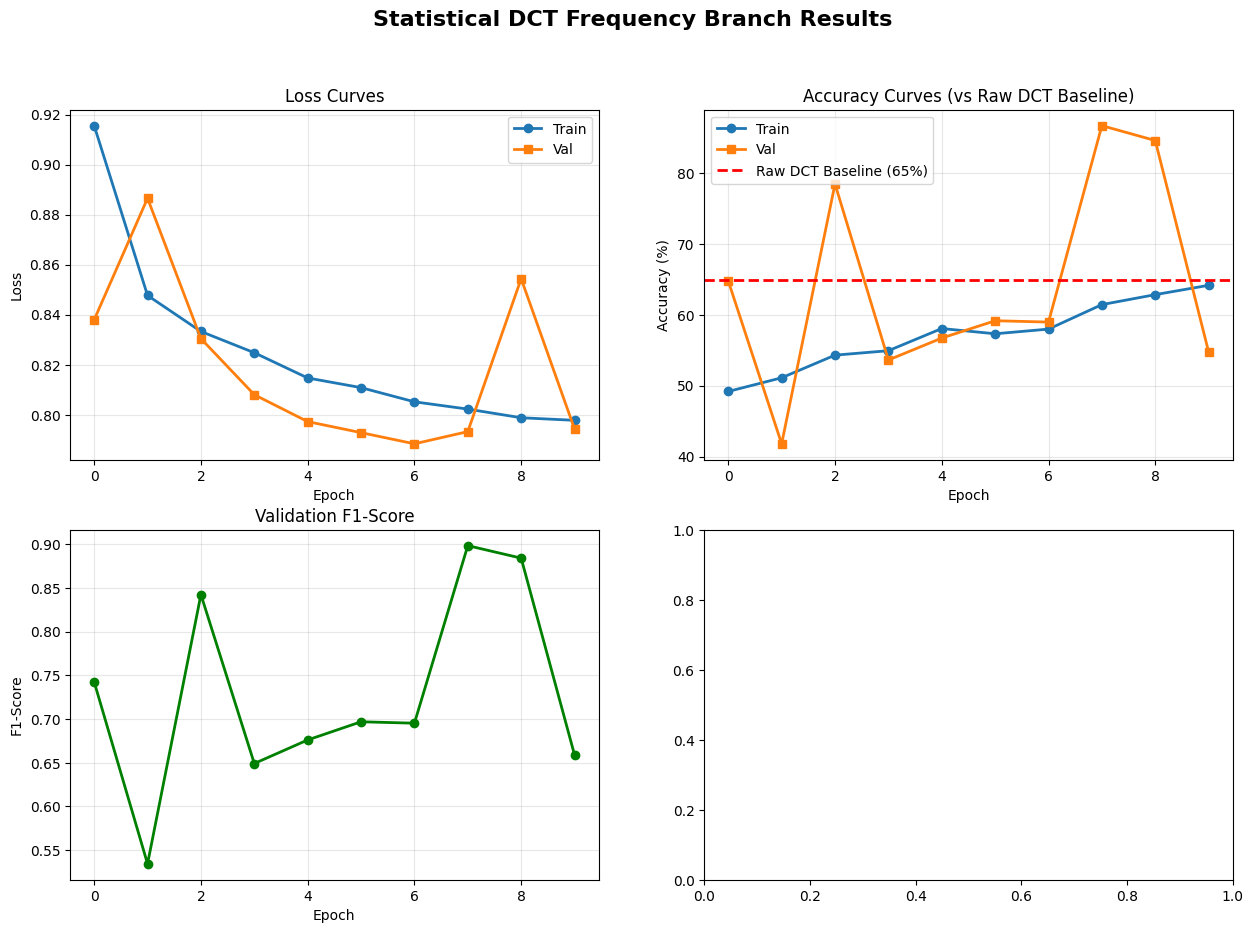

In [15]:
if dataset_ready and len(history['val_acc']) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Statistical DCT Frequency Branch Results', fontsize=16, fontweight='bold')

    axes[0, 0].plot(history['train_loss'], label='Train', marker='o', linewidth=2)
    axes[0, 0].plot(history['val_loss'], label='Val', marker='s', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Loss Curves')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(history['train_acc'], label='Train', marker='o', linewidth=2)
    axes[0, 1].plot(history['val_acc'], label='Val', marker='s', linewidth=2)
    axes[0, 1].axhline(y=65, color='r', linestyle='--', label='Raw DCT Baseline (65%)', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Accuracy Curves (vs Raw DCT Baseline)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(history['val_f1'], marker='o', linewidth=2, color='green')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1-Score')
    axes[1, 0].set_title('Validation F1-Score')
    axes[1, 0].grid(True, alpha=0.3)

    # Reload best model
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.eval()

    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.numpy())
            all_probs.extend(probs.cpu().numpy())

    cm = confusion_matrix(all_targets, all_preds)

    im = axes[1, 1].imshow(cm, cmap='Blues', aspect='auto')
    axes[1, 1].set_xticks([0, 1])
    axes[1, 1].set_yticks([0, 1])
    axes[1, 1].set_xticklabels(['Authentic', 'Tampered'])
    axes[1, 1].set_yticklabels(['Authentic', 'Tampered'])
    axes[1, 1].set_title('Confusion Matrix')

    for i in range(2):
        for j in range(2):
            text = axes[1, 1].text(j, i, cm[i, j], ha="center", va="center",
                                   color="white" if cm[i, j] > cm.max() / 2 else "black",
                                   fontsize=14, fontweight='bold')

    plt.colorbar(im, ax=axes[1, 1])
    plt.tight_layout()
    plt.savefig('statistical_dct_results.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print metrics
    print(f"\n{'='*80}")
    print("FINAL EVALUATION METRICS")
    print(f"{'='*80}")
    print(f"Accuracy:         {accuracy_score(all_targets, all_preds)*100:.2f}%")
    print(f"F1-Score:         {f1_score(all_targets, all_preds, average='weighted'):.4f}")
    try:
        auc = roc_auc_score(all_targets, all_probs)
        print(f"AUC-ROC:          {auc:.4f}")
    except:
        pass
    print(f"\nConfusion Matrix:")
    print(f"  TN={cm[0,0]:4d}  FP={cm[0,1]:4d}")
    print(f"  FN={cm[1,0]:4d}  TP={cm[1,1]:4d}")
    print(f"\n📊 IMPROVEMENT: +{best_val_acc - 65:.1f}% accuracy")
    print(f"   Raw DCT approach: 65%")
    print(f"   Statistical features: {best_val_acc:.2f}%")
    print(f"\n✅ Ready for CNN + ViT fusion!")
    print(f"{'='*80}")

## Export Model for Fusion

In [16]:
if dataset_ready:
    torch.save({
        'model_state_dict': model.state_dict(),
        'best_val_acc': best_val_acc,
        'architecture': 'StatisticalDCTClassifier',
        'out_channels': 128,
    }, 'statistical_dct_checkpoint.pth')

    print(f"\n✓ Model saved to statistical_dct_checkpoint.pth")
    print(f"  - Architecture: StatisticalDCTClassifier (7 statistical features)")
    print(f"  - Best accuracy: {best_val_acc:.2f}%")
    print(f"  - Ready for cross-attention fusion with CNN + ViT")
    print(f"\n🎯 Next steps:")
    print(f"   1. Use this StatisticalDCTFrequencyBranch in your full pipeline")
    print(f"   2. Add CNN branch (edge anomalies)")
    print(f"   3. Add ViT branch (global structure)")
    print(f"   4. Cross-attention fusion of all 3 branches")
    print(f"   5. Expected ensemble accuracy: 92-96%+")


✓ Model saved to statistical_dct_checkpoint.pth
  - Architecture: StatisticalDCTClassifier (7 statistical features)
  - Best accuracy: 86.74%
  - Ready for cross-attention fusion with CNN + ViT

🎯 Next steps:
   1. Use this StatisticalDCTFrequencyBranch in your full pipeline
   2. Add CNN branch (edge anomalies)
   3. Add ViT branch (global structure)
   4. Cross-attention fusion of all 3 branches
   5. Expected ensemble accuracy: 92-96%+
